In [101]:
from scipy.stats import boxcox
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error as mae


computers= pd.read_csv("Computers.csv")

In [102]:
computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


In [103]:
#mengecek tipe data
computers.info()

<class 'pandas.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   price    6259 non-null   int64
 1   speed    6259 non-null   int64
 2   hd       6259 non-null   int64
 3   ram      6259 non-null   int64
 4   screen   6259 non-null   int64
 5   cd       6259 non-null   str  
 6   multi    6259 non-null   str  
 7   premium  6259 non-null   str  
 8   ads      6259 non-null   int64
 9   trend    6259 non-null   int64
dtypes: int64(7), str(3)
memory usage: 489.1 KB


In [104]:
#mengecek nilai statistik dari data
computers.describe()

,price,speed,hd,ram,screen,ads,trend
count,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000
mean,2219.576610,52.011024,416.601694,8.286947,14.608723,221.301007,15.926985
std,580.803956,21.157735,258.548445,5.631099,0.905115,74.835284,7.873984
min,949.000000,25.000000,80.000000,2.000000,14.000000,39.000000,1.000000
25%,1794.000000,33.000000,214.000000,4.000000,14.000000,162.500000,10.000000
50%,2144.000000,50.000000,340.000000,8.000000,14.000000,246.000000,16.000000
75%,2595.000000,66.000000,528.000000,8.000000,15.000000,275.000000,21.500000
max,5399.000000,100.000000,2100.000000,32.000000,17.000000,339.000000,35.000000


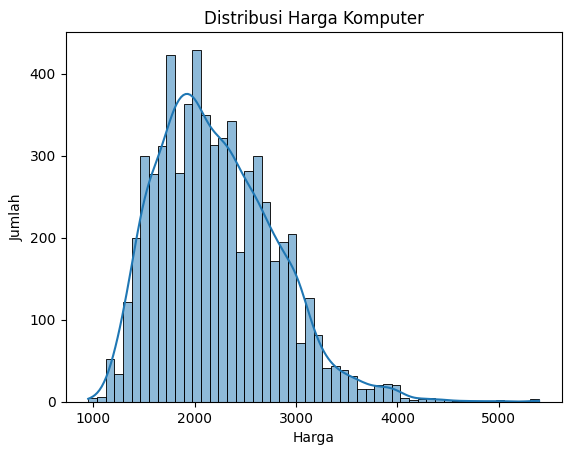

In [105]:
#melihat distribusi harga komputer
sns.histplot(computers['price'], kde=True);
plt.title('Distribusi Harga Komputer');
plt.xlabel('Harga');
plt.ylabel('Jumlah');

In [106]:
#melihat korelasi antar variabel
computers.corr(numeric_only=True)

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


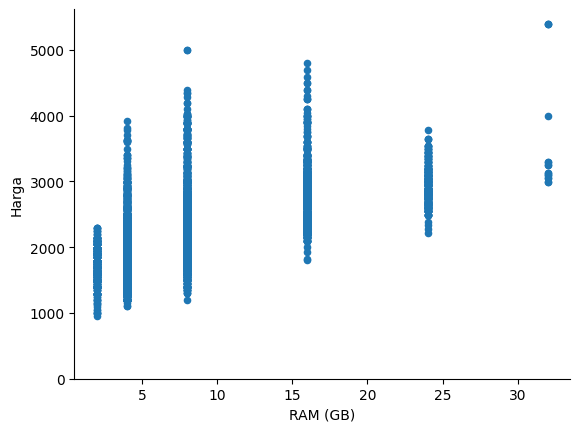

In [107]:
# melihat hubungan antara RAM dan harga komputer
computers.plot.scatter(x='ram', y='price').set_ylim(0)
plt.xlabel('RAM (GB)')
plt.ylabel('Harga')
sns.despine()

In [108]:
# melakukan regresi linier sederhana antara ram dan price
x = sm.add_constant(computers["ram"])
y = computers["price"]

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     3964.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        08:30:31   Log-Likelihood:                -47180.
No. Observations:                6259   AIC:                         9.436e+04
Df Residuals:                    6257   BIC:                         9.438e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1687.2925     10.221    165.073      0.0

Text(0, 0.5, 'Residuals')

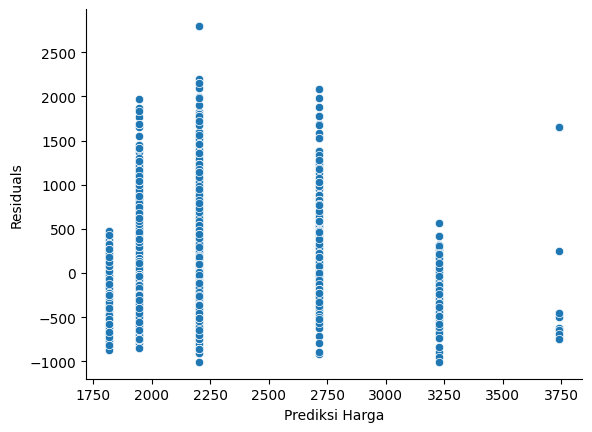

In [109]:
# membuat plot residuals
sns.scatterplot(x=model.predict(x), y=model.resid)

sns.despine()

plt.xlabel('Prediksi Harga')
plt.ylabel('Residuals')

In [110]:
# membuat prediksi harga komputer berdasarkan nilai ram
feature_values = [0, 2, 4, 8, 16, 32, 64]

predic_df = sm.add_constant(pd.DataFrame({"ram": feature_values}))

print(predic_df)

   const  ram
0    1.0    0
1    1.0    2
2    1.0    4
3    1.0    8
4    1.0   16
5    1.0   32
6    1.0   64


In [111]:
predictions = model.predict(predic_df)

predictions.index = feature_values

print(predictions)

0     1687.292537
2     1815.755790
4     1944.219043
8     2201.145550
16    2714.998564
32    3742.704591
64    5798.116644
dtype: float64


In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

computers = pd.read_csv("Computers.csv")
computers.tail()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
6254,1690,100,528,8,15,no,no,yes,39,35
6255,2223,66,850,16,15,yes,yes,yes,39,35
6256,2654,100,1200,24,15,yes,no,yes,39,35
6257,2195,100,850,16,15,yes,no,yes,39,35
6258,2490,100,850,16,17,yes,no,yes,39,35


In [113]:
#melihat korelasi antar variabel
computers.corr(numeric_only=True)

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


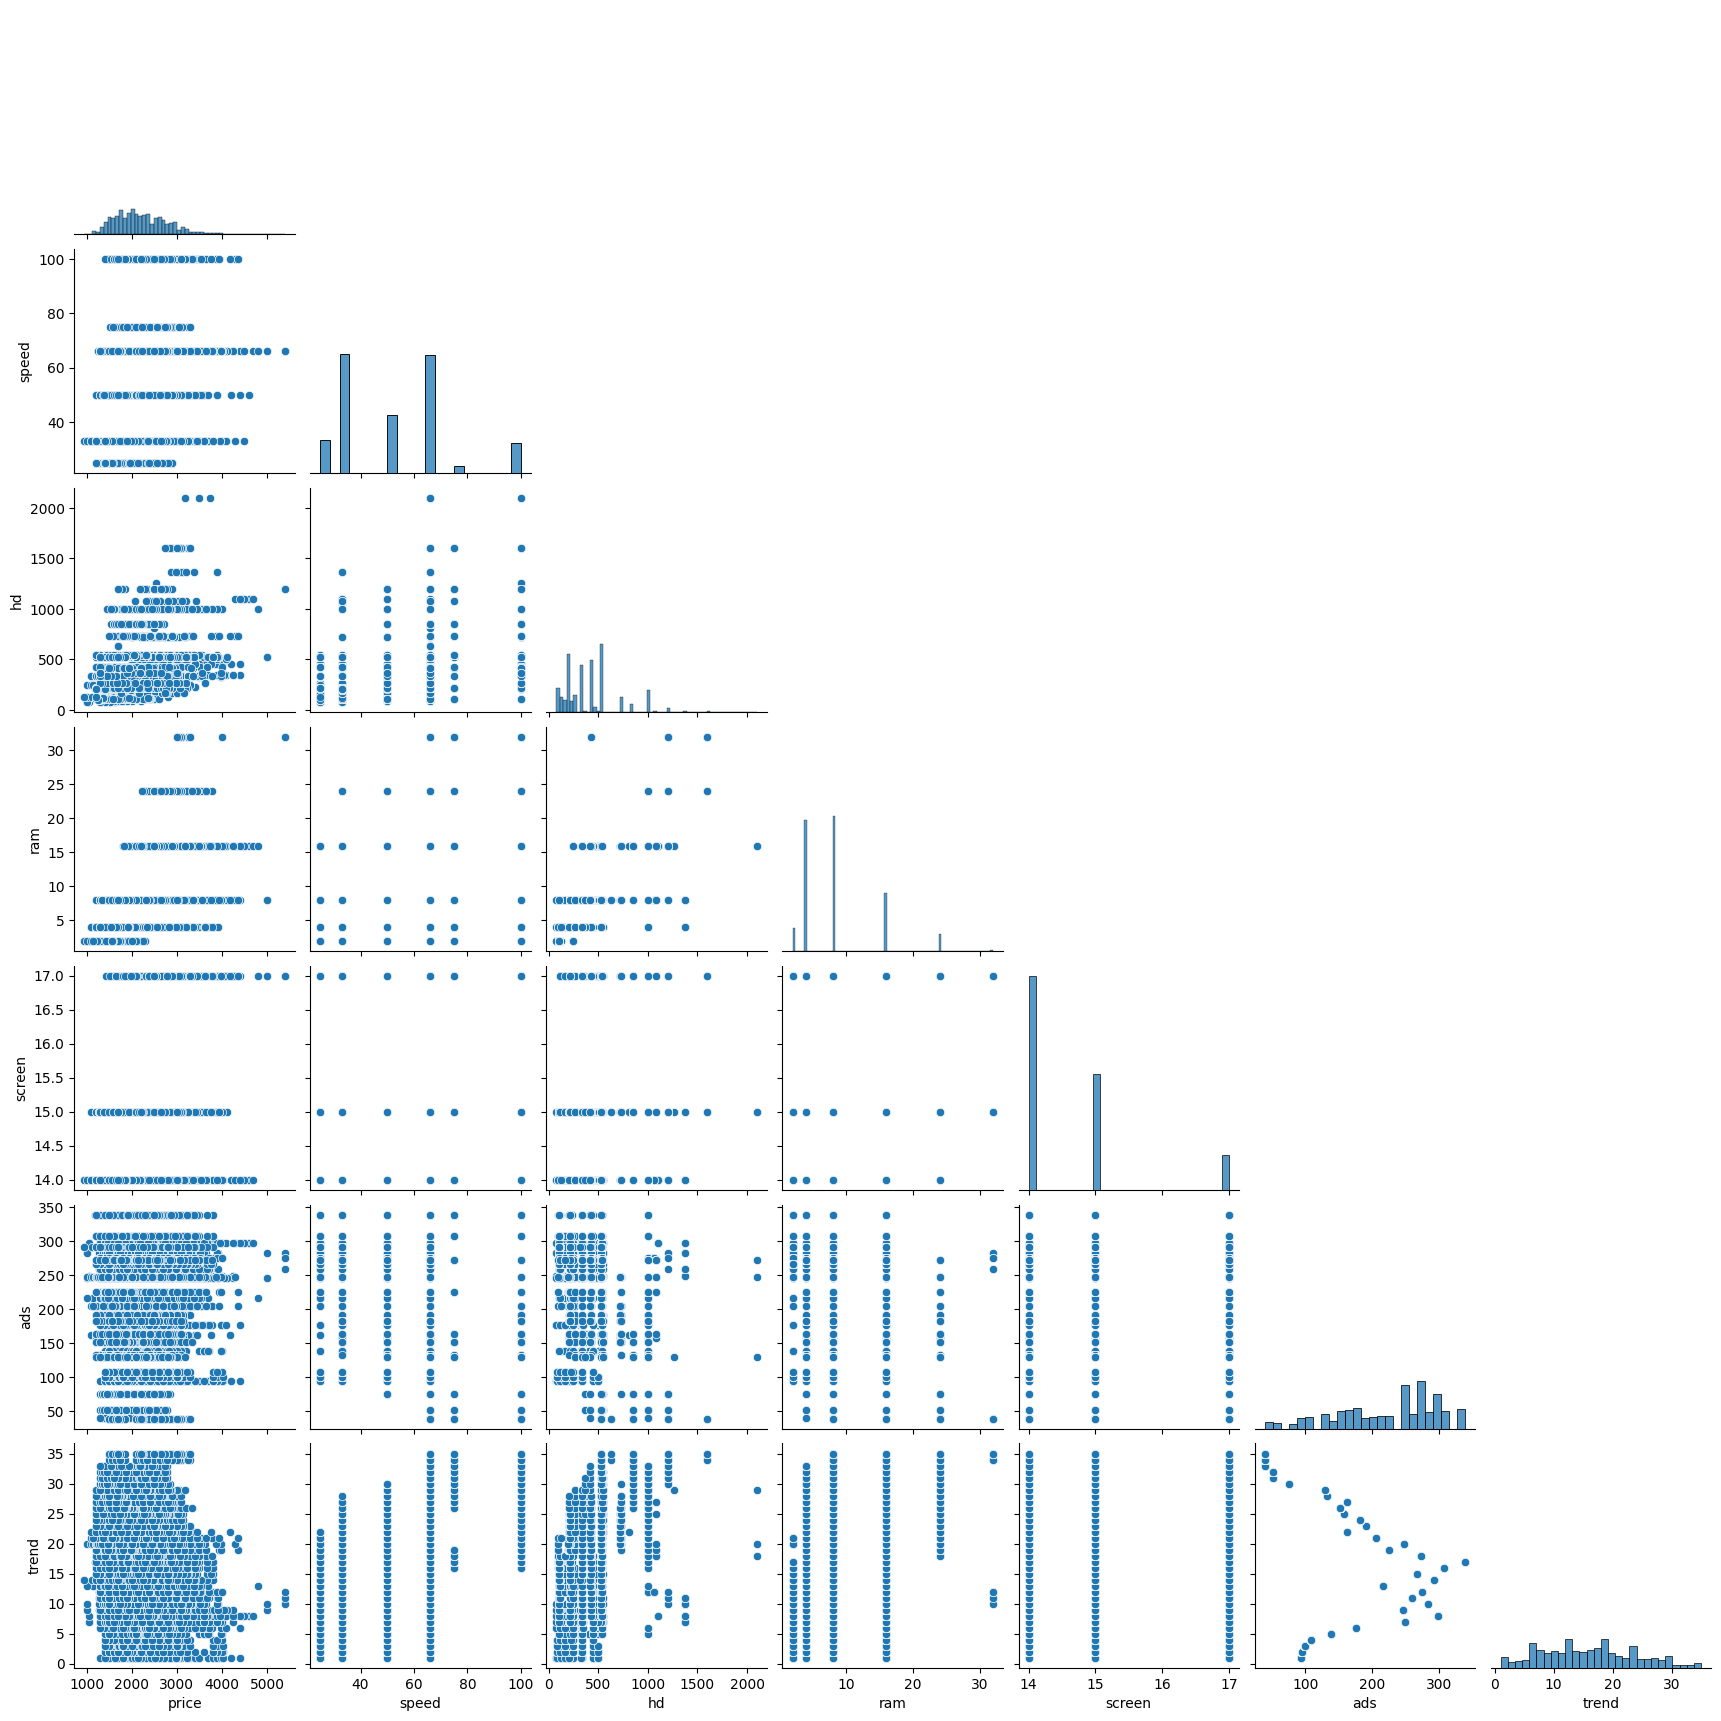

In [114]:
# melihat hubungan antara variabel numerik
sns.pairplot(computers, corner=True)

<Axes: xlabel='ads', ylabel='Count'>

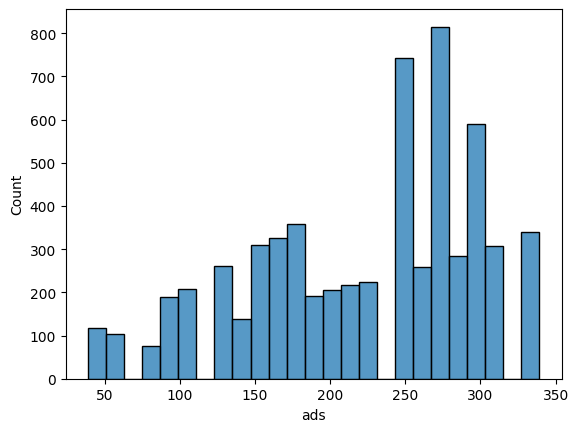

In [115]:
sns.histplot(computers['ads'])

Model Pertama

In [116]:
cols = ["ram", "speed", "hd", "screen"]

X = sm.add_constant(computers[cols])
y = computers["price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     1325.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        08:30:35   Log-Likelihood:                -46795.
No. Observations:                6259   AIC:                         9.360e+04
Df Residuals:                    6254   BIC:                         9.363e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3331     88.222      0.117      0.9

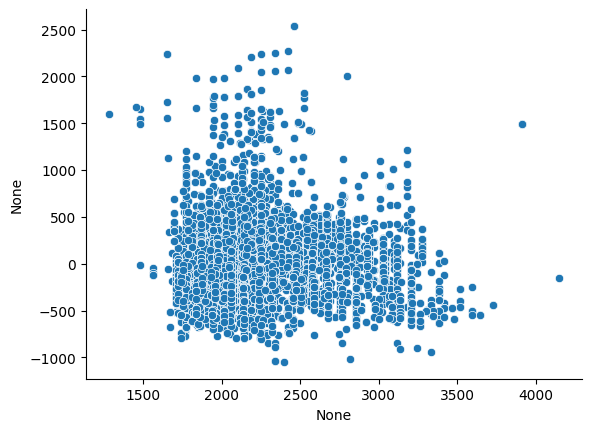

In [117]:
sns.scatterplot(x=model.predict(X), y=model.resid)
sns.despine()

# Model Kedua

In [118]:
kolom = ['ram','speed', 'hd','screen', 'ads', 'trend']
X = sm.add_constant(computers[kolom])
y = computers["price"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     2580.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        08:30:35   Log-Likelihood:                -44817.
No. Observations:                6259   AIC:                         8.965e+04
Df Residuals:                    6252   BIC:                         8.969e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -246.6755     66.371     -3.717      0.0

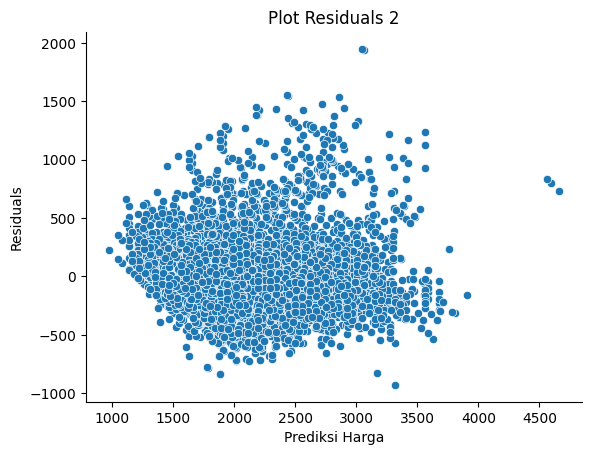

In [119]:
sns.scatterplot(x=model2.predict(X), y=model2.resid)
plt.title('Plot Residuals 2')
plt.xlabel('Prediksi Harga')
plt.ylabel('Residuals')
sns.despine()

# Metrik

In [120]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse

cols = ['ram','speed', 'hd','screen', 'ads', 'trend']
X = sm.add_constant(computers[cols])
y = computers["price"]

model = sm.OLS(y, X).fit()

print(f"MAE: {mae(y, model.predict())}")
print(f"MSE: {np.sqrt(mse(y, model.predict()))}")

MAE: 225.5632258662684
MSE: 311.5017500706834
